# Feature Importance Analysis
Permutation importance is used consistently across all three models (LSTM, TCN, SARIMAX) to allow fair comparison.  
Each feature is shuffled 10 times across test samples and the resulting change in RMSE is recorded.  
A positive value means the feature contributes to prediction accuracy; a negative value means the model performs better without it.

## 1. Setup

In [1]:
!pip install keras-tcn keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_squared_error
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
from tcn import TCN

# ── Shared constants ──────────────────────────────────────────────────────────
DL_FEATURES = ['water_level', 'temperature', 'precipitation', 'wind_speed']
SARIMAX_FEATURES = ['temperature', 'precipitation', 'wind_speed']
LOOKBACK = 24

test_df = pd.read_csv('uk_test.csv')

In [3]:
# ── Shared helper functions ───────────────────────────────────────────────────

def create_sequences(X_scaled, y_scaled, lookback):
    """Create 3-D sliding-window sequences for LSTM / TCN."""
    X, y = [], []
    for i in range(lookback, len(X_scaled)):
        X.append(X_scaled[i - lookback:i])
        y.append(y_scaled[i])
    return np.array(X), np.array(y).flatten()


def permutation_importance_dl(model, X_test, y_test, feature_names, n_repeats=10):
    """Permutation importance for deep learning models (LSTM / TCN)."""
    baseline_pred = model.predict(X_test, verbose=0).flatten()
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

    importances = {}
    for i, name in enumerate(feature_names):
        scores = []
        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            np.random.shuffle(X_permuted[:, :, i])
            pred = model.predict(X_permuted, verbose=0).flatten()
            rmse = np.sqrt(mean_squared_error(y_test, pred))
            scores.append(rmse - baseline_rmse)
        importances[name] = np.mean(scores)

    return importances, baseline_rmse


def permutation_importance_sarimax(model, test_df, feature_names, n_repeats=10):
    """Permutation importance for SARIMAX (2-D exogenous input)."""
    baseline_pred = model.get_forecast(
        steps=len(test_df), exog=test_df[feature_names]
    ).predicted_mean
    baseline_rmse = np.sqrt(mean_squared_error(test_df['water_level'], baseline_pred))

    importances = {}
    for feat in feature_names:
        scores = []
        for _ in range(n_repeats):
            exog_permuted = test_df[feature_names].copy()
            exog_permuted[feat] = np.random.permutation(exog_permuted[feat].values)
            pred = model.get_forecast(
                steps=len(test_df), exog=exog_permuted
            ).predicted_mean
            rmse = np.sqrt(mean_squared_error(test_df['water_level'], pred))
            scores.append(rmse - baseline_rmse)
        importances[feat] = np.mean(scores)

    return importances, baseline_rmse

## 2. LSTM Feature Importance
Model loaded from HuggingFace to avoid re-training.

In [4]:
# ── Load LSTM model & scalers ────────────────────────────────────────────────
lstm_model = load_model(hf_hub_download('Kozy9/GWLSTM', 'lstm_model.keras'))
scaler_X   = joblib.load(hf_hub_download('Kozy9/GWLSTM', 'scaler_X.pkl'))
scaler_y   = joblib.load(hf_hub_download('Kozy9/GWLSTM', 'scaler_y.pkl'))

# ── Prepare test sequences ───────────────────────────────────────────────────
X_scaled = scaler_X.transform(test_df[DL_FEATURES])
y_scaled = scaler_y.transform(test_df[['water_level']])
X_test_lstm, y_test_lstm = create_sequences(X_scaled, y_scaled, LOOKBACK)

# ── Compute importance ───────────────────────────────────────────────────────
lstm_importance, lstm_baseline = permutation_importance_dl(
    lstm_model, X_test_lstm, y_test_lstm, DL_FEATURES
)
print(f'Baseline RMSE (scaled): {lstm_baseline:.4f}')
print(lstm_importance)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Baseline RMSE (scaled): 0.0564
{'water_level': np.float64(0.04272904960626832), 'temperature': np.float64(0.02479780217319033), 'precipitation': np.float64(0.0032803196810857554), 'wind_speed': np.float64(0.006597561575642679)}


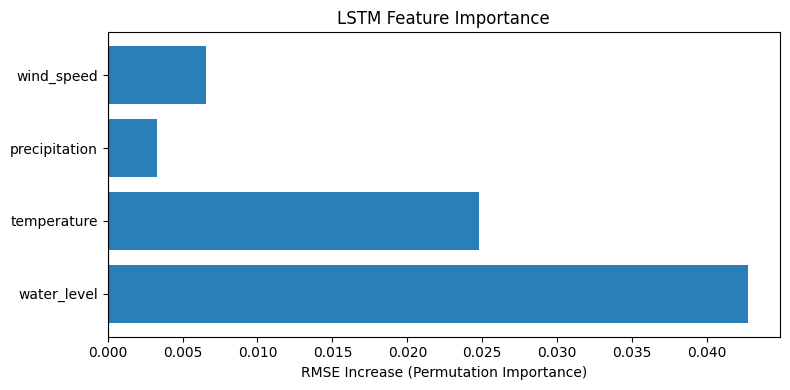

In [5]:
# ── LSTM importance plot ─────────────────────────────────────────────────────
names  = list(lstm_importance.keys())
values = list(lstm_importance.values())
colors = ['#e74c3c' if v < 0 else '#2980b9' for v in values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(names, values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('RMSE Increase (Permutation Importance)')
ax.set_title('LSTM Feature Importance')
plt.tight_layout()
plt.savefig('fig_lstm_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. TCN Feature Importance
Model loaded from HuggingFace to avoid re-training.

In [6]:
# ── Load TCN model & scalers ─────────────────────────────────────────────────
tcn_model       = load_model(hf_hub_download('Kozy9/GWTCN', 'tcn_model.keras'))
scaler_features = joblib.load(hf_hub_download('Kozy9/GWTCN', 'scaler_features.pkl'))
scaler_target   = joblib.load(hf_hub_download('Kozy9/GWTCN', 'scaler_target.pkl'))

# ── Prepare test sequences ───────────────────────────────────────────────────
X_scaled = scaler_features.transform(test_df[DL_FEATURES])
y_scaled = scaler_target.transform(test_df[['water_level']])
X_test_tcn, y_test_tcn = create_sequences(X_scaled, y_scaled, LOOKBACK)

# ── Compute importance ───────────────────────────────────────────────────────
tcn_importance, tcn_baseline = permutation_importance_dl(
    tcn_model, X_test_tcn, y_test_tcn, DL_FEATURES
)
print(f'Baseline RMSE (scaled): {tcn_baseline:.4f}')
print(tcn_importance)

Baseline RMSE (scaled): 0.0545
{'water_level': np.float64(0.04199078610192792), 'temperature': np.float64(0.024385804909841276), 'precipitation': np.float64(0.006174520855588669), 'wind_speed': np.float64(0.0038291454229148632)}


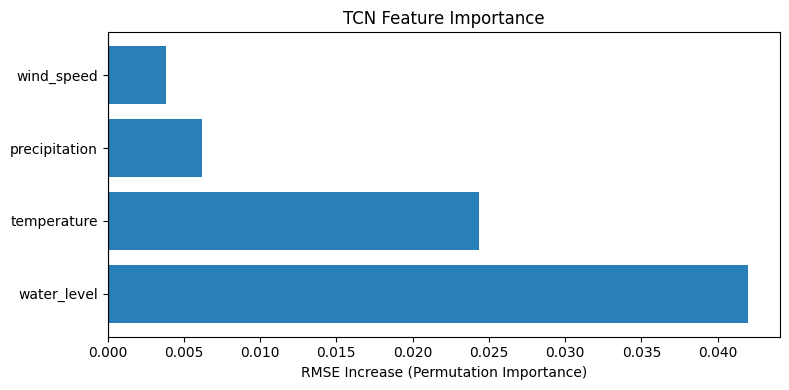

In [7]:
# ── TCN importance plot ──────────────────────────────────────────────────────
names  = list(tcn_importance.keys())
values = list(tcn_importance.values())
colors = ['#e74c3c' if v < 0 else '#2980b9' for v in values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(names, values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('RMSE Increase (Permutation Importance)')
ax.set_title('TCN Feature Importance')
plt.tight_layout()
plt.savefig('fig_tcn_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SARIMAX Feature Importance
SARIMAX captures the autoregressive effect of past water levels through its AR/MA components,  
so only the exogenous meteorological variables are tested here.

In [8]:
# ── Load SARIMAX model ───────────────────────────────────────────────────────
sarimax_model = joblib.load(hf_hub_download('Kozy9/GWSarimax', 'sarimax_model.pkl'))

# ── Compute importance ───────────────────────────────────────────────────────
sarimax_importance, sarimax_baseline = permutation_importance_sarimax(
    sarimax_model, test_df, SARIMAX_FEATURES
)
print(f'Baseline RMSE: {sarimax_baseline:.4f}')
print(sarimax_importance)

Baseline RMSE: 5.1540
{'temperature': np.float64(-0.0449642460547226), 'precipitation': np.float64(-0.00046327639044498883), 'wind_speed': np.float64(0.01662514279674756)}


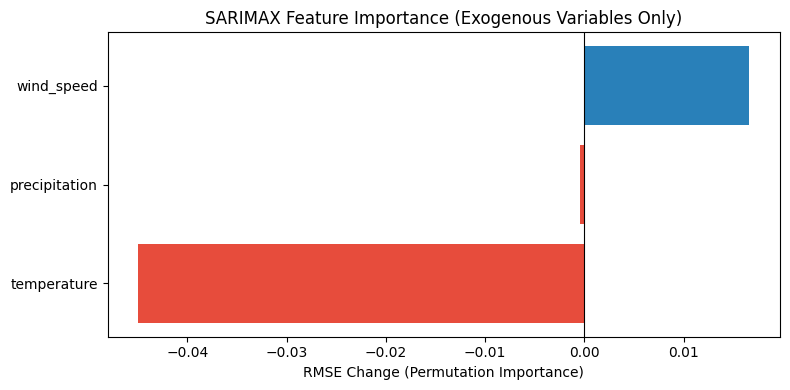

In [9]:
# ── SARIMAX importance plot ──────────────────────────────────────────────────
names  = list(sarimax_importance.keys())
values = list(sarimax_importance.values())
colors = ['#e74c3c' if v < 0 else '#2980b9' for v in values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(names, values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('RMSE Change (Permutation Importance)')
ax.set_title('SARIMAX Feature Importance (Exogenous Variables Only)')
plt.tight_layout()
plt.savefig('fig_sarimax_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Model Comparison
Side-by-side comparison of permutation importance across all three models.  
SARIMAX does not include water level as an exogenous feature since its autoregressive  
components capture that effect internally.

In [10]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'LSTM'   : lstm_importance,
    'TCN'    : tcn_importance,
}).T

# Add SARIMAX as a separate row (no water_level column)
sarimax_row = pd.DataFrame(sarimax_importance, index=['SARIMAX'])
sarimax_row['water_level'] = np.nan  # not applicable
summary = pd.concat([summary, sarimax_row])

summary = summary[['water_level', 'temperature', 'precipitation', 'wind_speed']]
summary.columns = ['Water Level', 'Temperature', 'Precipitation', 'Wind Speed']
print(summary.round(4).to_string())

         Water Level  Temperature  Precipitation  Wind Speed
LSTM          0.0427       0.0248         0.0033      0.0066
TCN           0.0420       0.0244         0.0062      0.0038
SARIMAX          NaN      -0.0450        -0.0005      0.0166


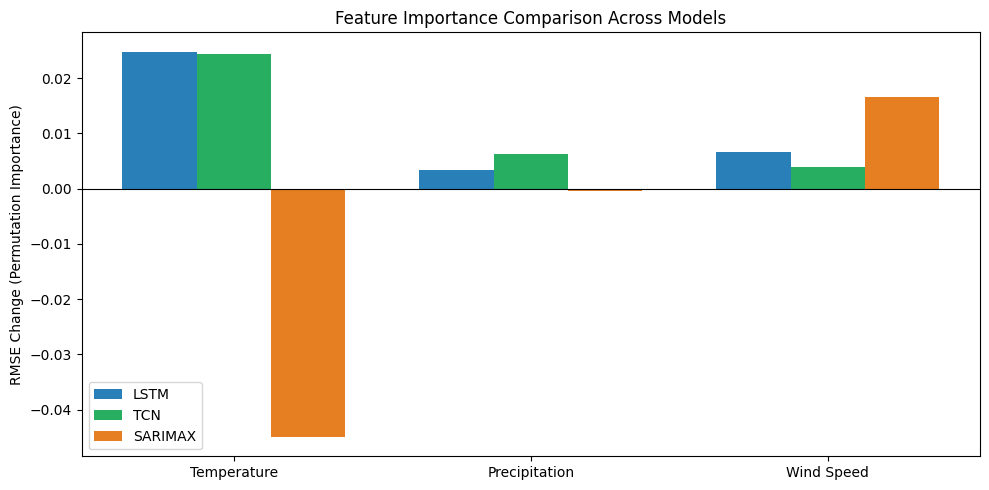

In [11]:
# ── Cross-model comparison chart ─────────────────────────────────────────────
shared_features = ['temperature', 'precipitation', 'wind_speed']
labels = ['Temperature', 'Precipitation', 'Wind Speed']
x = np.arange(len(shared_features))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width, [lstm_importance[f] for f in shared_features],
       width, label='LSTM', color='#2980b9')
ax.bar(x,         [tcn_importance[f] for f in shared_features],
       width, label='TCN', color='#27ae60')
ax.bar(x + width, [sarimax_importance[f] for f in shared_features],
       width, label='SARIMAX', color='#e67e22')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('RMSE Change (Permutation Importance)')
ax.set_title('Feature Importance Comparison Across Models')
ax.legend()
plt.tight_layout()
plt.savefig('fig_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()